# Reservoir Computing — 5-Step Training Pipeline

> Second Meeting — Implementation 

This notebook implements the complete **Echo State Network (ESN)** training procedure
described in the second meeting:

| Step | Action |
|------|--------|
| **①** | Pre-compute the Lorenz attractor — thermalize, then use as input $\vec{h}(t)$ |
| **②** | Drive the reservoir — simulate $\vec{h}(t) \to \vec{r}(t)$, store matrix $R$ |
| **③** | Define the readout: $\vec{h'}(t) = W^{\text{out}}\,\vec{r}(t)$ |
| **④** | Ridge regression — solve for $W^{\text{out}}$, target = $h(t + \Delta t)$ |
| **⑤** | Autonomous (closed-loop) prediction — 5 independent realisations, report MSE |

**Input signal**: all three Lorenz components $(x, y, z)$, i.e. $\vec{h}(t) \in \mathbb{R}^3$.

**5 runs**: five independent reservoirs (different random seeds for $W$ and $W^{\text{in}}$)
trained and evaluated identically — measures **variability across realisations** as
discussed in the first meeting ($\mathbb{E}[\text{Var}(r_i, c_k)]$).

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Helper functions (carried over from previous notebook)

These are the original functions from the first session.
`simulate` runs the reservoir **without input** (used for sanity checks);
we will add a driven version in Step ②.

In [9]:
def init_r(N, kind="uniform", scale=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    if kind == "uniform":  return rng.uniform(-scale, scale, size=N)
    if kind == "gaussian": return rng.normal(0.0, scale, size=N)
    if kind == "zeros":    return np.zeros(N)
    if kind == "ones":     return np.ones(N)
    raise ValueError("kind must be 'uniform', 'gaussian', 'zeros', or 'ones'")


def make_W(N, J, rng, kind="gaussian", p=None):
    if kind == "gaussian":
        return rng.normal(0.0, J / np.sqrt(N), size=(N, N))
    if kind == "erdos_renyi":
        if p is None:
            raise ValueError("need p")
        k = max(int(p * N), 1)
        return ((rng.random((N, N)) < p) * (J / k)).astype(float)
    raise ValueError("kind must be 'gaussian' or 'erdos_renyi'")


def simulate(r_0, W, time):
    """Reservoir without input — used for sanity checks from the first session."""
    r_0 = np.asarray(r_0, dtype=float)
    W   = np.asarray(W,   dtype=float)
    dt  = time[1] - time[0]
    T   = len(time)
    N   = len(r_0)
    R   = np.empty((T, N))
    R[0] = r_0
    for t in range(T - 1):
        r = R[t]
        R[t + 1] = r + dt * (-r + np.tanh(W @ r))
    return R

def annotate_params(fig, params_str):
    """
    Stamp parameter values onto a figure for reproducibility.
    Placed in the bottom-right corner as a small monospace text box.
    Call this just before plt.tight_layout() in every plot.
    """
    fig.text(
        0.99, 0.01, params_str,
        ha="right", va="bottom", fontsize=7.5, family="monospace", color="#333",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#fffde7",
                  edgecolor="#bbb", alpha=0.92),
        transform=fig.transFigure,
    )

---
## Step ① — Pre-compute the Lorenz Attractor (Thermalize)

We integrate the Lorenz-63 system

$$\dot{x} = \sigma(y - x), \qquad \dot{y} = x(\rho - z) - y, \qquad \dot{z} = xy - \beta z$$

with standard butterfly parameters $\sigma=10,\;\rho=28,\;\beta=8/3$.

**Key ideas:**
- Run long enough to **thermalize** 
- Use only the **attractor trajectory** as input $\vec{h}(t)$
- *"We give it to $\vec{h}$ — because it is difficult to predict"*
- Split into **training** and **test** windows

**Practical constraint:** $N \leq 300$; start with $N = 100$–$250$.

Transient discarded : 8,000 steps  (80.0 t.u.)
Training steps      : 10,000  (100.0 t.u.)
Test steps          : 2,000  (20.0  t.u.)


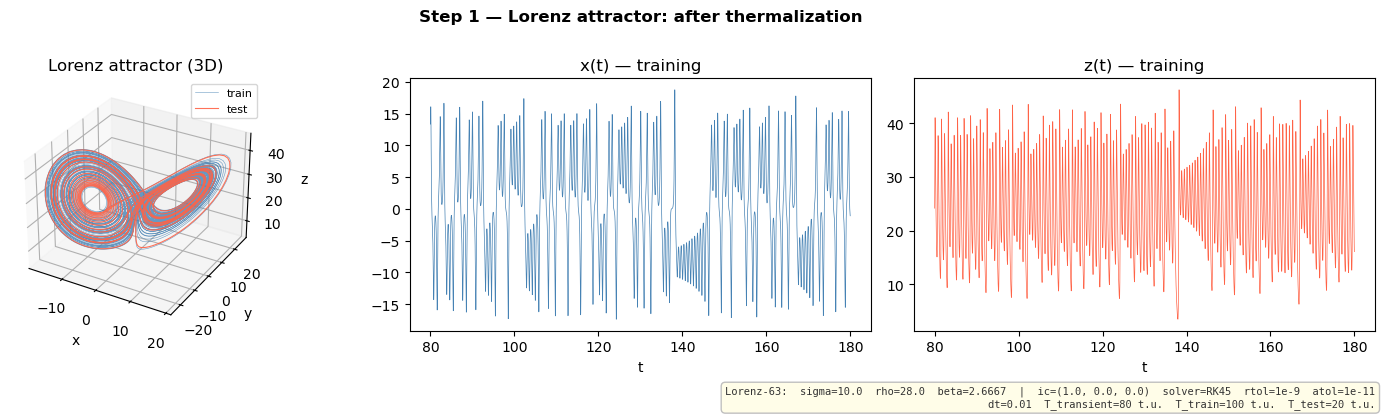

In [10]:
SIGMA_L, RHO_L, BETA_L = 10.0, 28.0, 8 / 3


def generate_lorenz(
    dt=0.01,
    T_total=200.0,
    T_transient=80.0,
    T_train=100.0,
    T_test=20.0,
    ic=(1.0, 0.0, 0.0),
):
    """
    Integrate Lorenz-63 and return labelled train / test splits.

    Returns
    -------
    dict  t_tr, u_tr (T_tr x 3), t_te, u_te (T_te x 3), dt
    """
    def _lorenz(t, s):
        x, y, z = s
        return [SIGMA_L * (y - x),
                x * (RHO_L - z) - y,
                x * y - BETA_L * z]

    t_eval = np.arange(0, T_total, dt)
    sol    = solve_ivp(_lorenz, [0, T_total], list(ic),
                       t_eval=t_eval, method="RK45", rtol=1e-9, atol=1e-11)

    xyz = sol.y.T          # (T_total/dt, 3)
    t   = sol.t

    i0  = int(T_transient / dt)                 # end of transient
    i1  = i0 + int(T_train / dt)               # end of training
    i2  = i1 + int(T_test  / dt)               # end of test

    print(f"Transient discarded : {i0:,} steps  ({T_transient} t.u.)")
    print(f"Training steps      : {i1 - i0:,}  ({T_train} t.u.)")
    print(f"Test steps          : {i2 - i1:,}  ({T_test}  t.u.)")

    return dict(
        t_tr=t[i0:i1], u_tr=xyz[i0:i1],
        t_te=t[i1:i2], u_te=xyz[i1:i2],
        dt=dt,
    )


lorenz_data = generate_lorenz()

# ── Visualisation ─────────────────────────────────────────────────────────────
u_tr = lorenz_data["u_tr"]
u_te = lorenz_data["u_te"]
t_tr = lorenz_data["t_tr"]
t_te = lorenz_data["t_te"]

fig = plt.figure(figsize=(15, 4))

ax3d = fig.add_subplot(131, projection="3d")
ax3d.plot(*u_tr.T, lw=0.4, color="steelblue", alpha=0.8, label="train")
ax3d.plot(*u_te.T, lw=0.8, color="tomato",    alpha=0.9, label="test")
ax3d.set_title("Lorenz attractor (3D)")
ax3d.set_xlabel("x"); ax3d.set_ylabel("y"); ax3d.set_zlabel("z")
ax3d.legend(fontsize=8)

for ax, comp, lbl, col in [
    (fig.add_subplot(132), u_tr[:, 0], "x(t) — training", "steelblue"),
    (fig.add_subplot(133), u_tr[:, 2], "z(t) — training", "tomato"),
]:
    ax.plot(t_tr, comp, lw=0.5, color=col)
    ax.set_title(lbl); ax.set_xlabel("t")

plt.suptitle("Step 1 — Lorenz attractor: after thermalization", fontweight="bold", y=1.01)
annotate_params(fig,
    f"Lorenz-63:  sigma={SIGMA_L}  rho={RHO_L}  beta={BETA_L:.4f}"
    f"  |  ic=(1.0, 0.0, 0.0)  solver=RK45  rtol=1e-9  atol=1e-11\n"
    f"dt={lorenz_data['dt']}  T_transient=80 t.u.  T_train=100 t.u.  T_test=20 t.u."
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

---
## Step ② — Simulate the Reservoir / Collect States

Drive the reservoir with the Lorenz input $\vec{h}(t) \in \mathbb{R}^3$ to obtain $\vec{r}(t)$:

$$r_i(t + \Delta t) = r_i(t) + \Delta t\left[-r_i(t) + S\!\left(\sum_j W_{ij}\,r_j(t) +
\sum_j W^{\text{in}}_{ij}\,h_j(t)\right)\right]$$

**Store history:** state matrix $R$ of shape $(T, N)$ — key ingredient for regression.

A **washout** period (first $N_{\text{washout}}$ steps) is discarded to let the reservoir
"forget" its initial condition and settle onto the attractor.

| Parameter | Value | Note |
|-----------|-------|------|
| $N$ | 250 | reservoir neurons |
| $J$ | 0.9 | edge of chaos, trains ✓ |
| $\sigma_{\text{in}}$ | 1.0 | input weight scale |
| $\Delta t$ | 0.01 | matches Lorenz integration step |
| $N_{\text{washout}}$ | 500 | warm-up steps discarded |

Building reservoir (seed=0):
  seed=0  spectral_radius=0.926  J=0.9  [stable — trains ✓]
  R_train shape : (9500, 250)   u_target shape : (9500, 3)


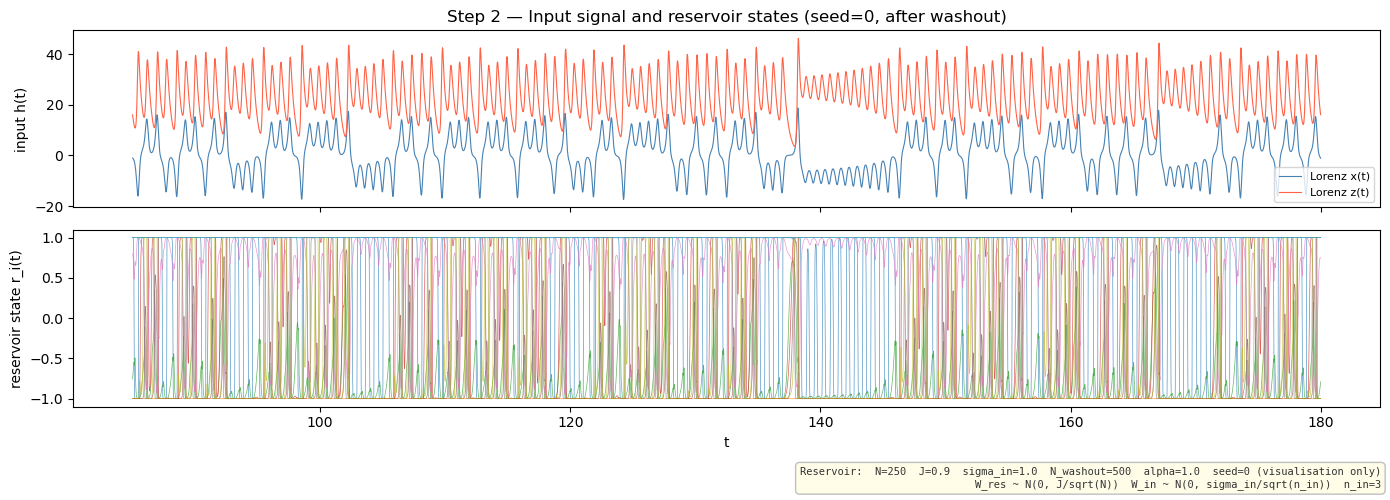

In [11]:
# ── Global hyper-parameters ────────────────────────────────────────────────────
N_RES     = 250      # reservoir neurons
J_RES     = 0.9      # coupling strength  (< 1 → trains; ≈ 1 → edge of chaos)
SIGMA_IN  = 1.0      # input weight std
N_WASHOUT = 500      # warm-up steps to discard


def build_reservoir(seed, n_in=3, N=N_RES, J=J_RES, sigma_in=SIGMA_IN):
    """
    Construct fixed random matrices W_res and W_in.

    Returns
    -------
    W_res  (N, N)    -- recurrent weight matrix, Gaussian, FIXED
    W_in   (N, n_in) -- input weight matrix,    Gaussian, FIXED
    """
    rng   = np.random.default_rng(seed)
    W_res = make_W(N, J, rng=rng, kind="gaussian")
    W_in  = rng.normal(0.0, sigma_in / np.sqrt(n_in), size=(N, n_in))

    rho = float(np.max(np.abs(np.linalg.eigvals(W_res))))
    regime = "chaotic — does NOT train" if J > 1 else "stable — trains ✓"
    print(f"  seed={seed}  spectral_radius={rho:.3f}  J={J}  [{regime}]")
    return W_res, W_in


def collect_states(lorenz_data, W_res, W_in, N_washout=N_WASHOUT, alpha=1.0):
    """
    Drive the reservoir open-loop with the training signal u_tr.

    Euler update (leak rate alpha=1 recovers the standard ESN equation):
        r(t+dt) = (1-alpha)*r(t) + alpha * tanh( W_res @ r(t) + W_in @ h(t) )

    Returns
    -------
    R_train   (T - N_washout, N)  -- reservoir state matrix
    u_target  (T - N_washout, 3)  -- aligned Lorenz signal (regression target)
    r_last    (N,)                -- final reservoir state (seed for closed-loop)
    """
    u_tr = lorenz_data["u_tr"]   # (T, 3)
    T, _ = u_tr.shape
    N    = W_res.shape[0]

    r = np.zeros(N)
    R = np.empty((T, N))

    for t in range(T):
        r    = (1 - alpha) * r + alpha * np.tanh(W_res @ r + W_in @ u_tr[t])
        R[t] = r

    R_train  = R[N_washout:]
    u_target = u_tr[N_washout:]

    print(f"  R_train shape : {R_train.shape}   u_target shape : {u_target.shape}")
    return R_train, u_target, R[-1].copy()


# ── Build one reservoir (seed=0) for visualisation ────────────────────────────
print("Building reservoir (seed=0):")
W_res0, W_in0 = build_reservoir(seed=0)

print("Collecting states:")
R_train0, u_target0, r_last0 = collect_states(lorenz_data, W_res0, W_in0)

# ── Visualisation ─────────────────────────────────────────────────────────────
t_plot = lorenz_data["t_tr"][N_WASHOUT:]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(t_plot, u_target0[:, 0], lw=0.8, color="steelblue", label="Lorenz x(t)")
axes[0].plot(t_plot, u_target0[:, 2], lw=0.8, color="tomato",    label="Lorenz z(t)")
axes[0].set_ylabel("input h(t)")
axes[0].legend(fontsize=8)
axes[0].set_title("Step 2 — Input signal and reservoir states (seed=0, after washout)")

for i in range(10):
    axes[1].plot(t_plot, R_train0[:, i], lw=0.5, alpha=0.75)
axes[1].set_ylabel("reservoir state r_i(t)")
axes[1].set_xlabel("t")

annotate_params(fig,
    f"Reservoir:  N={N_RES}  J={J_RES}  sigma_in={SIGMA_IN}  N_washout={N_WASHOUT}"
    f"  alpha=1.0  seed=0 (visualisation only)\n"
    f"W_res ~ N(0, J/sqrt(N))  W_in ~ N(0, sigma_in/sqrt(n_in))  n_in=3"
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

---
## Steps ③ & ④ — Readout Definition and Ridge Regression

### Step ③ — Readout

The output is a **linear combination of reservoir states** — the *only* trained part:

$$\hat{h}(t) = W^{\text{out}} \cdot \vec{r}(t)$$

### Step ④ — Ridge Regression for $W^{\text{out}}$

Target: predict the **next time step** $h(t + \Delta t)$.

$$W^{\text{out}} = \underset{W}{\arg\min}\;\left\| W \cdot R - H_{\text{target}} \right\|^2 + \lambda \|W\|^2$$

Closed-form solution:

$$W^{\text{out}} = \left(R^\top R + \lambda I\right)^{-1} R^\top H_{\text{target}}$$

where $R$ is the state matrix $(T \times N)$ and $H_{\text{target}} = h(t + \Delta t)$.

> **From the notes:** *"Series should overlap → no risk of overfitting"*
> (the readout is a single linear layer — no deep model to overfit).

We also sweep $\lambda$ to confirm the chosen regularisation is reasonable.

Train RMSE   x=0.10253   y=0.07364   z=0.33085


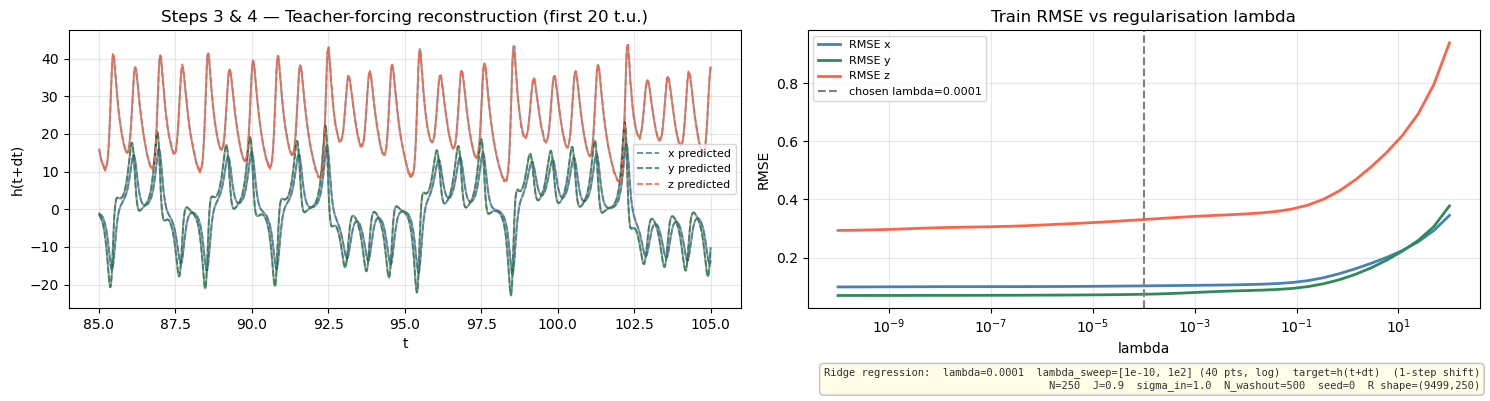

In [12]:
LAM_REG = 1e-4   # ridge regularisation strength


def train_readout(R_train, u_target, lam=LAM_REG):
    """
    Solve ridge regression:  W_out = (R'R + lam*I)^{-1} R' H_target

    The target is h(t + dt) — the NEXT time step of the input.
    We shift u_target by 1 step to obtain the regression target.

    Returns
    -------
    W_out      (N, 3)   -- output weight matrix
    u_pred     (T-1, 3) -- teacher-forcing predictions
    rmse       (3,)     -- per-component RMSE on training set
    """
    # shift by 1: current states predict NEXT input  (h(t) -> h(t+dt))
    R = R_train[:-1]       # (T-1, N)
    H = u_target[1:]       # (T-1, 3)  target = h(t+dt)

    N   = R.shape[1]
    RtR = R.T @ R
    RtH = R.T @ H
    W_out  = np.linalg.solve(RtR + lam * np.eye(N), RtH)   # (N, 3)

    u_pred = R @ W_out                                       # (T-1, 3)
    rmse   = np.sqrt(np.mean((u_pred - H) ** 2, axis=0))
    return W_out, u_pred, rmse


# ── Train on seed=0 reservoir ─────────────────────────────────────────────────
W_out0, u_pred_train0, rmse0 = train_readout(R_train0, u_target0)
print(f"Train RMSE   x={rmse0[0]:.5f}   y={rmse0[1]:.5f}   z={rmse0[2]:.5f}")

# ── Lambda sweep ──────────────────────────────────────────────────────────────
lambdas = np.logspace(-10, 2, 40)
rmse_sweep = np.array(
    [train_readout(R_train0, u_target0, lam=l)[2] for l in lambdas]
)   # (40, 3)

# ── Visualisation ─────────────────────────────────────────────────────────────
t_tf   = lorenz_data["t_tr"][N_WASHOUT + 1:]   # aligned time axis (shift by 1)
H_true = u_target0[1:]                          # true next-step targets
n_show = 2000

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Panel 1: teacher-forcing reconstruction
comp_colors = ["steelblue", "seagreen", "tomato"]
for i, (lbl, col) in enumerate(zip(["x", "y", "z"], comp_colors)):
    axes[0].plot(t_tf[:n_show], H_true[:n_show, i],
                 lw=1.5, color="k", alpha=0.4)
    axes[0].plot(t_tf[:n_show], u_pred_train0[:n_show, i],
                 lw=1.2, ls="--", color=col, label=f"{lbl} predicted")
axes[0].set_title("Steps 3 & 4 — Teacher-forcing reconstruction (first 20 t.u.)")
axes[0].set_xlabel("t")
axes[0].set_ylabel("h(t+dt)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Panel 2: lambda sweep
for i, (lbl, col) in enumerate(zip(["x", "y", "z"], comp_colors)):
    axes[1].plot(lambdas, rmse_sweep[:, i], lw=2, color=col, label=f"RMSE {lbl}")
axes[1].axvline(LAM_REG, ls="--", color="gray", lw=1.5, label=f"chosen lambda={LAM_REG}")
axes[1].set_xscale("log")
axes[1].set_title("Train RMSE vs regularisation lambda")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("RMSE")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

annotate_params(fig,
    f"Ridge regression:  lambda={LAM_REG}  lambda_sweep=[1e-10, 1e2] (40 pts, log)"
    f"  target=h(t+dt)  (1-step shift)\n"
    f"N={N_RES}  J={J_RES}  sigma_in={SIGMA_IN}  N_washout={N_WASHOUT}  seed=0"
    f"  R shape=({'{}'},{N_RES})".format(len(R_train0)-1)
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

---
## Step ⑤ — Autonomous (Closed-Loop) Prediction — 5 Runs

Once $W^{\text{out}}$ is trained, the loop is **closed**:
the readout at step $t$ feeds back as the reservoir input at step $t+1$.

**Substitution (from the notes):**
> *"Substitute $\vec{h}(t)$ by $\vec{h'}(t)$* — replace the true Lorenz input
> with the reservoir's own predicted output (autonomous / generative mode).


**5 runs = 5 independent reservoir realisations** (different random seeds → different
$W$ and $W^{\text{in}}$). This measures **variability across realisations** —
$\mathbb{E}[\text{Var}(r_i, c_k)]$.

In [13]:
def run_closed_loop(lorenz_data, W_res, W_in, W_out, r_seed, alpha=1.0):
    """
    Autonomous prediction over the test window.

    The reservoir's own readout is fed back as input (no ground-truth signal).

    Returns
    -------
    U_pred  (T_te, 3)  -- predicted Lorenz trajectory
    mse     float      -- mean squared error vs ground truth
    """
    u_te   = lorenz_data["u_te"]   # (T_te, 3)
    T_te   = len(u_te)
    r      = r_seed.copy()
    U_pred = np.empty((T_te, 3))

    for t in range(T_te):
        u_hat  = r @ W_out                                          # Step ③
        r      = (1 - alpha) * r + alpha * np.tanh(W_res @ r + W_in @ u_hat)  # feedback
        U_pred[t] = u_hat

    mse = float(np.mean((U_pred - u_te) ** 2))
    return U_pred, mse


# ── Run all 5 realisations ─────────────────────────────────────────────────────
N_RUNS     = 5
run_colors = ["#264653", "#2A9D8F", "#E76F51", "#F4A261", "#A8DADC"]
mses       = []
preds      = []

for seed in range(N_RUNS):
    print(f"\n--- Run {seed + 1}/{N_RUNS} (seed={seed}) ---")
    W_res_s, W_in_s          = build_reservoir(seed=seed)
    R_tr_s, u_tgt_s, r_last  = collect_states(lorenz_data, W_res_s, W_in_s)
    W_out_s, _, rmse_s       = train_readout(R_tr_s, u_tgt_s)
    U_pred_s, mse_s          = run_closed_loop(lorenz_data, W_res_s, W_in_s,
                                                W_out_s, r_last)
    mses.append(mse_s)
    preds.append(U_pred_s)
    print(f"  Train RMSE (x,y,z) = {rmse_s.round(5)}")
    print(f"  Closed-loop MSE    = {mse_s:.5f}")

print("\n=== Summary ===")
for i, mse in enumerate(mses):
    print(f"  Run {i+1}: MSE = {mse:.5f}")
print(f"  Mean MSE : {np.mean(mses):.5f}")
print(f"  Std  MSE : {np.std(mses):.5f}")


--- Run 1/5 (seed=0) ---
  seed=0  spectral_radius=0.926  J=0.9  [stable — trains ✓]
  R_train shape : (9500, 250)   u_target shape : (9500, 3)
  Train RMSE (x,y,z) = [0.10253 0.07364 0.33085]
  Closed-loop MSE    = 1241.89936

--- Run 2/5 (seed=1) ---
  seed=1  spectral_radius=0.941  J=0.9  [stable — trains ✓]
  R_train shape : (9500, 250)   u_target shape : (9500, 3)
  Train RMSE (x,y,z) = [0.09628 0.07911 0.21269]
  Closed-loop MSE    = 372.32161

--- Run 3/5 (seed=2) ---
  seed=2  spectral_radius=0.911  J=0.9  [stable — trains ✓]
  R_train shape : (9500, 250)   u_target shape : (9500, 3)
  Train RMSE (x,y,z) = [0.11465 0.08452 0.27355]
  Closed-loop MSE    = 553.42540

--- Run 4/5 (seed=3) ---
  seed=3  spectral_radius=0.943  J=0.9  [stable — trains ✓]
  R_train shape : (9500, 250)   u_target shape : (9500, 3)
  Train RMSE (x,y,z) = [0.1609  0.10729 0.41676]
  Closed-loop MSE    = 85.94798

--- Run 5/5 (seed=4) ---
  seed=4  spectral_radius=0.949  J=0.9  [stable — trains ✓]
  R_tr

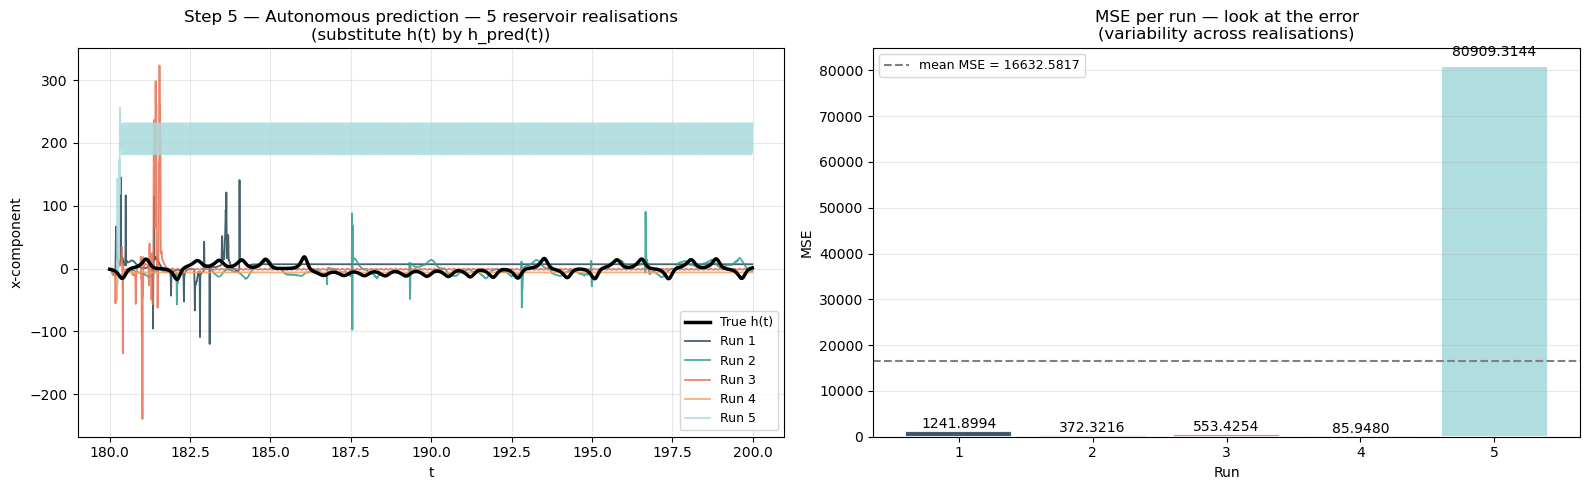

Best run: 4  (MSE = 85.94798)


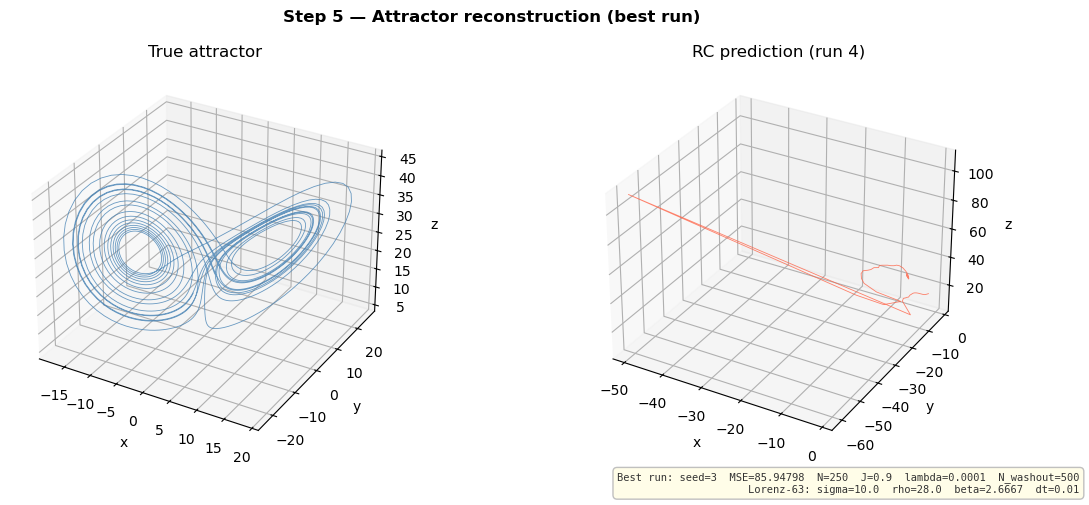

In [14]:
# ── Visualisation: 5-run comparison ───────────────────────────────────────────
t_te   = lorenz_data["t_te"]
u_te   = lorenz_data["u_te"]
n_show = min(2000, len(t_te))   # show first 20 t.u. for readability

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Panel 1: predicted x(t) for each run vs ground truth ─────────────────────
axes[0].plot(t_te[:n_show], u_te[:n_show, 0],
             color="black", lw=2.5, label="True h(t)", zorder=10)
for i, (pred, col) in enumerate(zip(preds, run_colors)):
    axes[0].plot(t_te[:n_show], pred[:n_show, 0],
                 lw=1.3, alpha=0.85, color=col, label=f"Run {i + 1}")
axes[0].set_title(
    "Step 5 — Autonomous prediction — 5 reservoir realisations\n"
    "(substitute h(t) by h_pred(t))"
)
axes[0].set_xlabel("t")
axes[0].set_ylabel("x-component")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Panel 2: MSE bar chart (from the notes) ───────────────────────────────────
bars = axes[1].bar(range(1, N_RUNS + 1), mses,
                   color=run_colors, edgecolor="white", linewidth=1.5, alpha=0.9)
axes[1].axhline(np.mean(mses), color="gray", ls="--", lw=1.5, label=f"mean MSE = {np.mean(mses):.4f}")
for bar, mse in zip(bars, mses):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.02,
                 f"{mse:.4f}",
                 ha="center", va="bottom", fontsize=10)
axes[1].set_title("MSE per run — look at the error\n(variability across realisations)")
axes[1].set_xlabel("Run")
axes[1].set_ylabel("MSE")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ── Bonus: 3D attractor comparison for best run ───────────────────────────────
best_run = int(np.argmin(mses))
print(f"Best run: {best_run + 1}  (MSE = {mses[best_run]:.5f})")

fig2 = plt.figure(figsize=(12, 5))
for col_idx, (data, lbl, col) in enumerate([
    (u_te[:n_show],                "True attractor",   "steelblue"),
    (preds[best_run][:n_show],     f"RC prediction (run {best_run+1})", "tomato"),
]):
    ax = fig2.add_subplot(1, 2, col_idx + 1, projection="3d")
    ax.plot(*data.T, lw=0.6, color=col, alpha=0.8)
    ax.set_title(lbl); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
fig2.suptitle("Step 5 — Attractor reconstruction (best run)", fontweight="bold")

annotate_params(fig2,
    f"Best run: seed={best_run}  MSE={mses[best_run]:.5f}"
    f"  N={N_RES}  J={J_RES}  lambda={LAM_REG}  N_washout={N_WASHOUT}\n"
    f"Lorenz-63: sigma={SIGMA_L}  rho={RHO_L}  beta={BETA_L:.4f}  dt={lorenz_data['dt']}"
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

---
## Summary

| Step | What was done | Key object |
|------|---------------|------------|
| **①** | Lorenz-63 integrated; transient ($T=80$ t.u.) discarded | $\vec{h}(t) \in \mathbb{R}^3$ |
| **②** | Reservoir driven open-loop; washout (500 steps) discarded | $R \in \mathbb{R}^{T \times N}$ |
| **③** | Readout defined as linear map: $\hat{h}(t) = W^{\text{out}}\vec{r}(t)$ | $W^{\text{out}} \in \mathbb{R}^{N \times 3}$ |
| **④** | Ridge regression solves for $W^{\text{out}}$; target = $h(t+\Delta t)$ | $\lambda = 10^{-4}$ |
| **⑤** | Loop closed; 5 independent realisations evaluated by MSE | variability across $W, W^{\text{in}}$ |

**Parameters used:**

| Parameter | Value | Note |
|-----------|-------|------|
| $N$ | 250 | from notes: start with 100–300 |
| $J$ | 0.9 | $<1$ → trains; $\approx 1$ → edge of chaos |
| $\Delta t$ | 0.01 | matches Lorenz integration |
| $\lambda$ | $10^{-4}$ | ridge regularisation |
| $W^{\text{in}}$ | Gaussian, fixed | $\sigma = 1/\sqrt{n_{\text{in}}}$ |
| $W^{\text{out}}$ | Gaussian init, **trained** | only trained component |

> **Key result:** Different random realisations of the reservoir yield different MSEs —
> quantifying the **variability** $\mathbb{E}[\text{Var}(r_i, c_k)]$ discussed in the first meeting.
> The spread tells us how sensitive prediction quality is to the random choice of $W$.